# **AI Driven Customer Segmentation for E-Commerce**

---



This project aims to develop a AI driven customer segmentation model that will enable the e-commerce platform to personalize marketing campaigns, improve customer retention, and ultimately increase sales.

The project will utilize the E-commerce Customer Behavior dataset from kaggle focussing on the following :

● **Customer Demographics:** Age, gender, location, membership type etc.

● **Purchase History:** Products purchased, purchase frequency, transaction value

● **Customer Feedback:** Product reviews, satisfaction level/complaints

***********************
**DATA PREPARATION**

---


*********************

**Data Loading and Exploration**

In [1]:
# ----------------------------------------
# Import the Libraries
# ----------------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform, zscore, loguniform
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import silhouette_score,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')


1.   Load and Inspect the Data

In [2]:
# Load the dataset
try:
    df = pd.read_csv('/content/drive/MyDrive/Berkley/mlai/capstone_project/data/E-commerce_Customer_Behavior.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: E-commerce_Customer_Behavior.csv not found. Please ensure the file is in the correct directory.")
    exit()
# Check data types and missing values
df.info()
df.isnull().sum()

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


In [3]:
# Check first few rows
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


2. Data Cleaning - Handle missing values,Correct data types, Remove duplicates,Detect and optionally handle outliers.

In [4]:
# Drop rows with missing Satisfaction Level - 2 missing values
df = df.dropna(subset=['Satisfaction Level'])

# Drop Customer ID - (not needed for modeling)
df = df.drop('Customer ID', axis=1)

In [5]:
####Categorical  data###
categorical_data = df.describe(include=['object'])
print(categorical_data.head())

####Numerical  data###
numerical_data = df.describe(include=['int64', 'float64'])
print(numerical_data.head())

# Discount Applied as integer - Correct data types
df['Discount Applied'] = df['Discount Applied'].astype(int)

# Confirm changes
df.info()


       Gender      City Membership Type Satisfaction Level
count     348       348             348                348
unique      2         6               3                  3
top      Male  New York            Gold          Satisfied
freq      175        59             117                125
              Age  Total Spend  Items Purchased  Average Rating  \
count  348.000000   348.000000       348.000000      348.000000   
mean    33.577586   847.793103        12.632184        4.023563   
std      4.878024   361.692375         4.146079        0.579145   
min     26.000000   410.800000         7.000000        3.000000   
25%     30.000000   505.750000         9.000000        3.500000   

       Days Since Last Purchase  
count                348.000000  
mean                  26.614943  
std                   13.474750  
min                    9.000000  
25%                   15.000000  
<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 349
Data columns (total 10 columns)

In [6]:
#Handle outliers
# Calculate Z-scores for numerical columns
# Get the list of numerical column names from the numerical_data DataFrame
numerical_cols_list = numerical_data.columns

# Select only the numerical columns from the original DataFrame df
df_numerical = df[numerical_cols_list]

# Calculate Z-scores for these numerical columns
z_scores = df_numerical.apply(zscore)

# Identify rows with any Z-score > 3 or < -3
outliers = (np.abs(z_scores) > 3).any(axis=1)

print(f"Number of outliers detected: {outliers.sum()}")

Number of outliers detected: 0


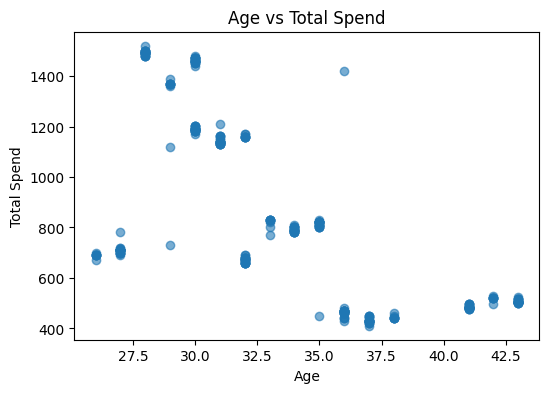

Scatter plot saved to: /content/drive/MyDrive/Berkley/mlai/capstone_project/images/outliers/scatter_outliers_Age.png


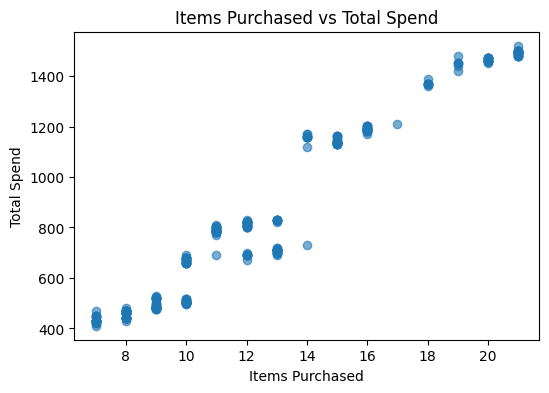

Scatter plot saved to: /content/drive/MyDrive/Berkley/mlai/capstone_project/images/outliers/scatter_outliers_Items Purchased.png


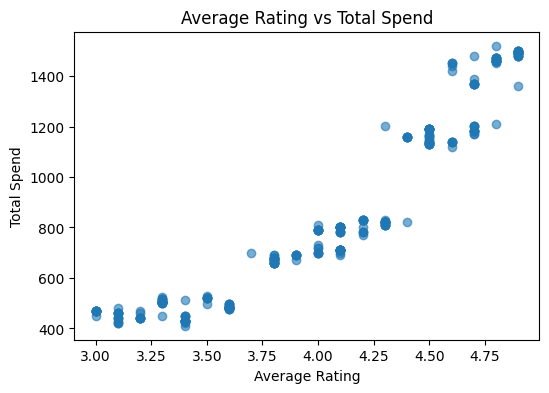

Scatter plot saved to: /content/drive/MyDrive/Berkley/mlai/capstone_project/images/outliers/scatter_outliers_Average Rating.png


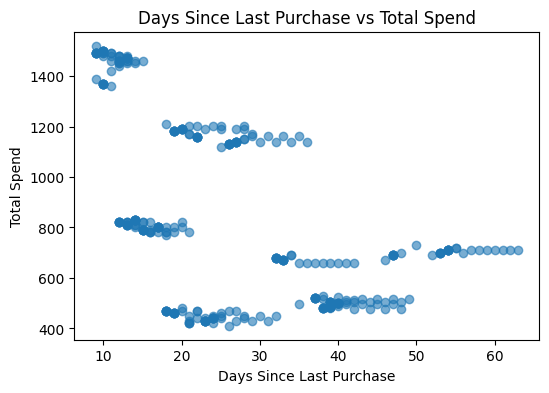

Scatter plot saved to: /content/drive/MyDrive/Berkley/mlai/capstone_project/images/outliers/scatter_outliers_Days Since Last Purchase.png


In [7]:
# Scatter plots with target
target = 'Total Spend'  # Example target
numerical_cols = ['Age', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df[target], alpha=0.6)
    plt.title(f'{col} vs {target}')
    plt.xlabel(col)
    plt.ylabel(target)

    filepath = f'/content/drive/MyDrive/Berkley/mlai/capstone_project/images/outliers/scatter_outliers_{col}.png'
    plt.savefig(filepath)
    plt.show()
    plt.close()  # Always close to avoid overlapping plots
    print(f"Scatter plot saved to: {filepath}")

######Interpretation
Outliers - "Age vs Total Spend" : There are a few data points that stand out, such as the individual around age 35 with very high spending, and the individual near age 29.5 with lower spending than their peers. These could be anomalies or represent unique customer segments. No other outliers detected.

3. Exploratory Data Analysis (EDA) - Univariate plots (histograms, boxplots),
Bivariate/multivariate plots (scatterplots, heatmaps), Identify patterns and relationships.


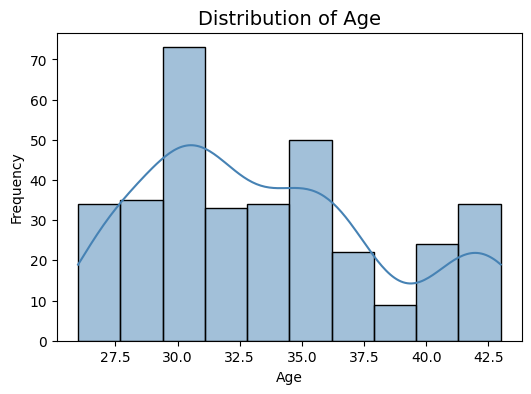

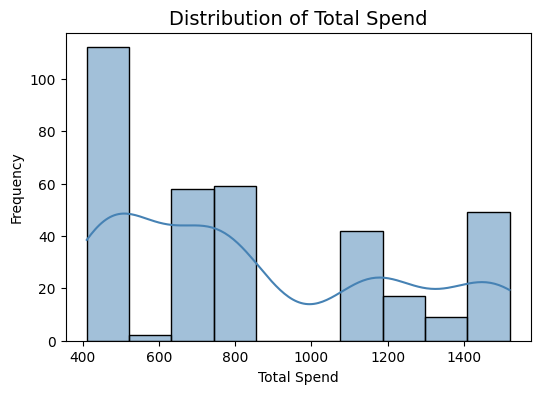

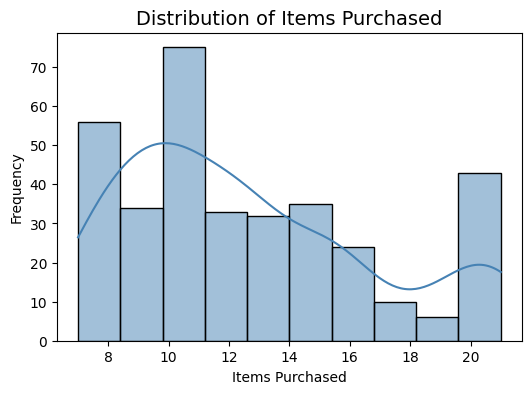

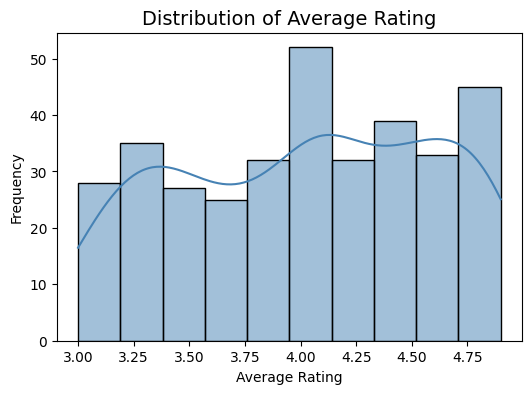

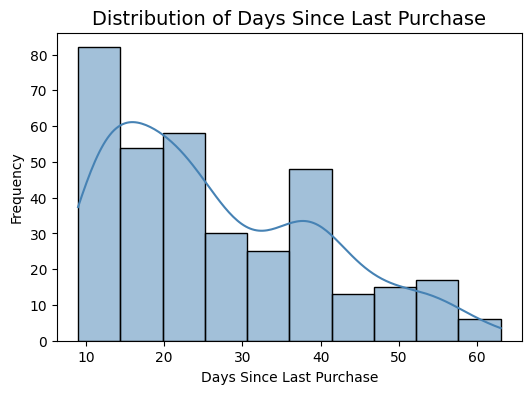

In [8]:
#EDA Univariate Analysis
numeric_cols = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color="steelblue")
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    filepath = f'/content/drive/MyDrive/Berkley/mlai/capstone_project/images/eda/eda_{col}.png'
    plt.savefig(filepath)
    plt.show()


######Interpretation
Distribution of "Age" is clearly multimodal with prominent peaks around 30-31, 35-36, and 42-43 years, indicating distinct age concentrations within the dataset.

Distribution of "Total Spend" is clearly multimodal, exhibiting several distinct peaks. The KDE curve highlights at least three or possibly four prominent modes, indicating that total spending tends to cluster around specific values rather than being evenly distributed.

Distribution of "Items Purchased" is multimodal, highlighting several preferred or common quantities of items that customers purchase, particularly around 7-8, 10-11, 14, and 20 items.

Distribution of "Average Rating" is multimodal, showing clear concentrations of ratings around 3.2-3.3, 4.0-4.1, and 4.7-4.8. This implies a non-uniform distribution of customer satisfaction or quality perception, with several preferred or typical average rating values.

Distribution of "Days Since Last Purchase" is multimodal, highlighting several preferred or typical intervals for repeat purchases, especially around 10-15, 20-25, and 35-40 days.


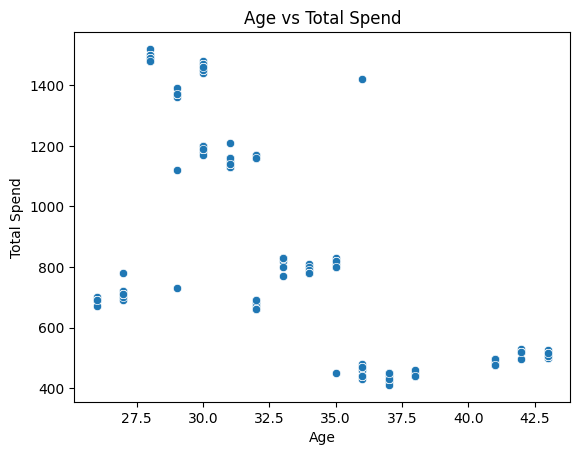

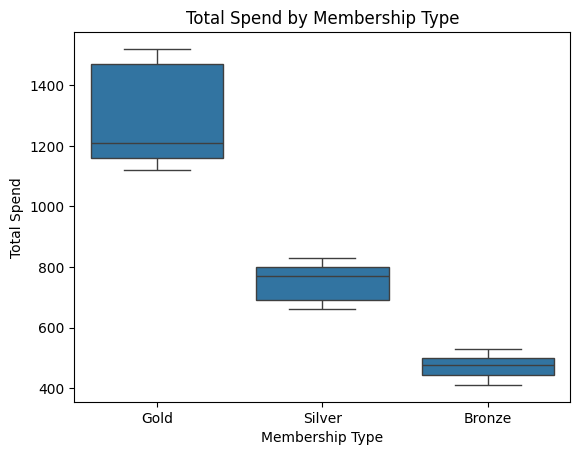

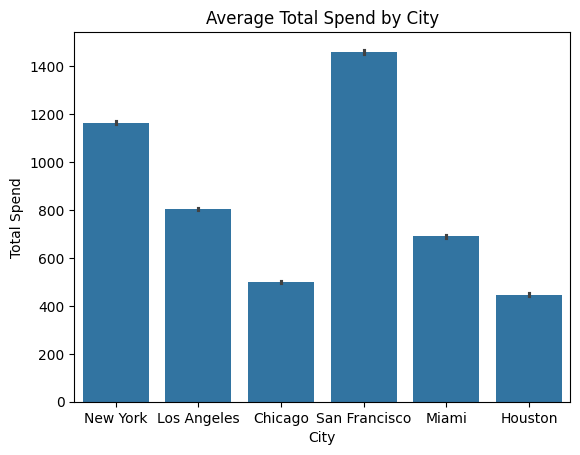

In [9]:
# EDA Bivariate Visualization

# Scatter Plots (Numerical vs. Numerical)
sns.scatterplot(data=df, x='Age', y='Total Spend')
plt.title('Age vs Total Spend')
filepath = f'/content/drive/MyDrive/Berkley/mlai/capstone_project/images/eda/bivar_age_spend.png'
plt.savefig(filepath)
plt.show()

# Box Plots (Categorical vs. Numerical)
sns.boxplot(data=df, x='Membership Type', y='Total Spend')
plt.title('Total Spend by Membership Type')
filepath = f'/content/drive/MyDrive/Berkley/mlai/capstone_project/images/eda/bivar_spend_memtype.png'
plt.savefig(filepath)
plt.show()

# Bar Plots (Categorical vs. Numerical - showing means/medians with error bars)
sns.barplot(data=df, x='City', y='Total Spend', estimator=np.mean) # or estimator=np.median
plt.title('Average Total Spend by City')
filepath = f'/content/drive/MyDrive/Berkley/mlai/capstone_project/images/eda/bivar_spend_city.png'
plt.savefig(filepath)
plt.show()


##### Inference
Younger customers, particularly those in their late 20s to early 30s, tend to have higher total spending. As customers age, their spending generally declines, although there might be specific age segments (like the 41-43 group) that maintain a slightly higher, albeit still lower than younger groups, spending level. The outlier suggests an individual who defies the general age-spending trend.

4. Feature Engineering -  Create new features (e.g., RFM, tenure, average satisfaction), Encode categorical variables and Scale/normalize features if needed.

In [10]:
#Create new feature -  RFM Features (Recency, Frequency, Monetary) these are standard in customer segmentation.

# Recency (already available)
df['Recency'] = df['Days Since Last Purchase']

# Frequency (using Items Purchased)
df['Frequency'] = df['Items Purchased']

# Monetary (using Total Spend)
df['Monetary'] = df['Total Spend']

# Simulate tenure as a function of frequency and recency
df['Tenure'] = df['Frequency'] + df['Recency']

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 349
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    348 non-null    object 
 1   Age                       348 non-null    int64  
 2   City                      348 non-null    object 
 3   Membership Type           348 non-null    object 
 4   Total Spend               348 non-null    float64
 5   Items Purchased           348 non-null    int64  
 6   Average Rating            348 non-null    float64
 7   Discount Applied          348 non-null    int64  
 8   Days Since Last Purchase  348 non-null    int64  
 9   Satisfaction Level        348 non-null    object 
 10  Recency                   348 non-null    int64  
 11  Frequency                 348 non-null    int64  
 12  Monetary                  348 non-null    float64
 13  Tenure                    348 non-null    int64  
dtypes: float64(3), 

In [11]:
#Ordinal encoding
satisfaction_map = {
    'Unsatisfied': 1,
    'Neutral': 2,
    'Satisfied': 3,
}
# Create the new column with meaningful scores
df['Satisfaction Score'] = df['Satisfaction Level'].map(satisfaction_map)

average_satisfaction = df['Satisfaction Score'].mean()
print(f"\nAverage Satisfaction Score: {average_satisfaction:.2f}")

# Drop the original 'Satisfaction Level' column
df = df.drop('Satisfaction Level', axis=1)
df.info()


Average Satisfaction Score: 2.03
<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 349
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    348 non-null    object 
 1   Age                       348 non-null    int64  
 2   City                      348 non-null    object 
 3   Membership Type           348 non-null    object 
 4   Total Spend               348 non-null    float64
 5   Items Purchased           348 non-null    int64  
 6   Average Rating            348 non-null    float64
 7   Discount Applied          348 non-null    int64  
 8   Days Since Last Purchase  348 non-null    int64  
 9   Recency                   348 non-null    int64  
 10  Frequency                 348 non-null    int64  
 11  Monetary                  348 non-null    float64
 12  Tenure                    348 non-null    int64  
 13  Satisfaction Score        348 non-nu

In [12]:
#One-Hot Encoding for Nominal Categorical Variables (Gender, City, Membership Type): This is generally best for avoiding false ordinality.
nominal_cols = ['Gender', 'City', 'Membership Type']

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.info()
df.head()

# Save the DataFrame to a CSV file to refer to modelling notebook
output_filename = 'encoded_customer_data.csv'
df.to_csv(output_filename, index=False)
print(f"\nDataFrame saved to '{output_filename}'")

<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 349
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       348 non-null    int64  
 1   Total Spend               348 non-null    float64
 2   Items Purchased           348 non-null    int64  
 3   Average Rating            348 non-null    float64
 4   Discount Applied          348 non-null    int64  
 5   Days Since Last Purchase  348 non-null    int64  
 6   Recency                   348 non-null    int64  
 7   Frequency                 348 non-null    int64  
 8   Monetary                  348 non-null    float64
 9   Tenure                    348 non-null    int64  
 10  Satisfaction Score        348 non-null    int64  
 11  Gender_Male               348 non-null    int64  
 12  City_Houston              348 non-null    int64  
 13  City_Los Angeles          348 non-null    int64  
 14  City_Miami     

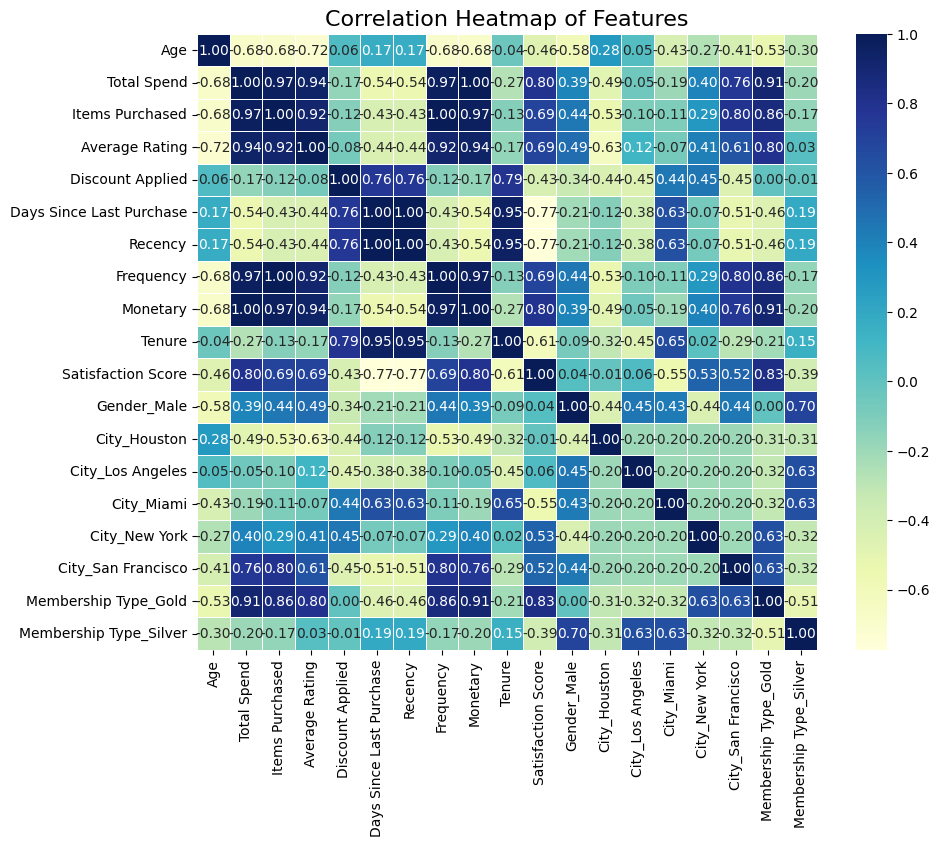

In [13]:
#EDA Correlation Heatmap - Multivariate visualization.
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Features', fontsize=16)
filepath = f'/content/drive/MyDrive/Berkley/mlai/capstone_project/images/eda/multi_heatmap.png'
plt.savefig(filepath)
plt.show()


######Interpretation
This heatmap provides a comprehensive overview of the linear relationships between all features, highlighting strong dependencies and independent variables
The color intensity and hue indicate the strength and direction of the correlation. Darker blue/green indicates stronger positive correlation, while lighter yellow/green indicates weaker or negative correlation (depending on the scale).
Spending-Related Group: Total Spend, Items Purchased, Average Rating, Membership Type, and City are all highly positively correlated with each other. This forms a strong cluster where increases in one generally correspond to increases in the others.

In [14]:
#Scale/Normalize the feature

numerical_features = [
    'Age', 'Total Spend', 'Items Purchased', 'Average Rating',
    'Days Since Last Purchase', 'Recency', 'Frequency', 'Monetary', 'Tenure','Discount Applied'
    ]

# Create a StandardScaler instance
scaler = StandardScaler()

df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("\nDataFrame head after scaling numerical features:")
print(df[numerical_features].head())
print("\nDescriptive statistics of scaled features:")
print(df[numerical_features].describe())

df.info()

df.describe()


DataFrame head after scaling numerical features:
        Age  Total Spend  Items Purchased  Average Rating  \
0 -0.939761     0.754230         0.330381        0.996757   
1  0.086720    -0.186319        -0.394236        0.132172   
2  1.934386    -0.933192        -0.877314       -1.078247   
3 -0.734465     1.751261         1.538076        1.169674   
4 -1.350354    -0.352721         0.088842       -0.040745   

   Days Since Last Purchase   Recency  Frequency  Monetary    Tenure  \
0                 -0.120022 -0.120022   0.330381  0.754230 -0.020125   
1                 -0.640260 -0.640260  -0.394236 -0.186319 -0.834481   
2                  1.143413  1.143413  -0.877314 -0.933192  0.957103   
3                 -1.086179 -1.086179   1.538076  1.751261 -0.671610   
4                  2.109570  2.109570   0.088842 -0.352721  2.341508   

   Discount Applied  
0          0.994269  
1         -1.005764  
2          0.994269  
3         -1.005764  
4          0.994269  

Descriptive stati

,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Recency,Frequency,Monetary,Tenure,Satisfaction Score,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership Type_Gold,Membership Type_Silver
count,3.480000e+02,3.480000e+02,3.480000e+02,3.480000e+02,3.480000e+02,3.480000e+02,3.480000e+02,3.480000e+02,3.480000e+02,3.480000e+02,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,-7.210069e-16,7.465293e-17,-1.244215e-16,4.252665e-16,-6.508204e-17,-2.041789e-17,-2.041789e-17,-1.244215e-16,7.465293e-17,2.450147e-16,2.025862,0.502874,0.160920,0.169540,0.166667,0.169540,0.166667,0.336207,0.336207
std,1.001440e+00,1.001440e+00,1.001440e+00,1.001440e+00,1.001440e+00,1.001440e+00,1.001440e+00,1.001440e+00,1.001440e+00,1.001440e+00,0.832979,0.500712,0.367986,0.375769,0.373215,0.375769,0.373215,0.473091,0.473091
min,-1.555650e+00,-1.209930e+00,-1.360392e+00,-1.769915e+00,-1.005764e+00,-1.309138e+00,-1.309138e+00,-1.360392e+00,-1.209930e+00,-1.241659e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.344650e-01,-9.470357e-01,-8.773142e-01,-9.053300e-01,-1.005764e+00,-8.632195e-01,-8.632195e-01,-8.773142e-01,-9.470357e-01,-7.530455e-01,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-3.238725e-01,-1.871492e-01,-1.526971e-01,1.321722e-01,9.942693e-01,-2.686616e-01,-2.686616e-01,-1.526971e-01,-1.871492e-01,-3.458674e-01,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.026086e-01,8.660877e-01,5.719200e-01,8.238404e-01,9.942693e-01,8.461345e-01,8.461345e-01,5.719200e-01,8.660877e-01,6.313601e-01,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.934386e+00,1.861457e+00,2.021154e+00,1.515509e+00,9.942693e-01,2.704128e+00,2.704128e+00,2.021154e+00,1.861457e+00,2.992993e+00,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Inference - The scaling operation using StandardScaler has been successfully executed. All selected numerical features now have a mean of approximately 0 and a standard deviation of approximately 1.

5. Feature Selection  - Correlation analysis, Recursive Feature Elimination, and Keep only the most useful features.

In [15]:
#Checking the dominating feature
features = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Discount Applied',
    'Days Since Last Purchase',
    'Recency',
    'Frequency',
    'Monetary',
    'Tenure',
    'Gender_Male',
    'City_Houston',
    'City_Los Angeles',
    'City_Miami',
    'City_New York',
    'City_San Francisco',
    'Membership Type_Gold',
    'Membership Type_Silver'
]
df['Satisfaction Score'] = df['Satisfaction Score'].astype(int)
target = df['Satisfaction Score']

# Split the data into training and testing sets
X = df[features]
y = target
print(df[features].head())

print("Head of the selected features after preprocessing:")
print(X.head())

print("\nAccuracy scores for individual features:")
for feature in features:
    try:
        scores = cross_val_score(LogisticRegression(max_iter=1000,
                                                    solver='lbfgs', # Recommended for multi-class
                                                    multi_class='auto' # Automatically chooses 'multinomial' for >2 classes
                                                   ),
                                 df[[feature]],
                                 df['Satisfaction Score'], # Use 'Satisfaction Score' as the target
                                 cv=5,
                                 scoring='f1_weighted', error_score='raise')
        print(f"{feature}: Accuracy Score = {scores.mean():.4f}")
    except Exception as e:
        print(f"Error for feature {feature}: {e}")



        Age  Total Spend  Items Purchased  Average Rating  Discount Applied  \
0 -0.939761     0.754230         0.330381        0.996757          0.994269   
1  0.086720    -0.186319        -0.394236        0.132172         -1.005764   
2  1.934386    -0.933192        -0.877314       -1.078247          0.994269   
3 -0.734465     1.751261         1.538076        1.169674         -1.005764   
4 -1.350354    -0.352721         0.088842       -0.040745          0.994269   

   Days Since Last Purchase   Recency  Frequency  Monetary    Tenure  \
0                 -0.120022 -0.120022   0.330381  0.754230 -0.020125   
1                 -0.640260 -0.640260  -0.394236 -0.186319 -0.834481   
2                  1.143413  1.143413  -0.877314 -0.933192  0.957103   
3                 -1.086179 -1.086179   1.538076  1.751261 -0.671610   
4                  2.109570  2.109570   0.088842 -0.352721  2.341508   

   Gender_Male  City_Houston  City_Los Angeles  City_Miami  City_New York  \
0            0 

In [16]:
# Detect/Remove Leaky Features

# Step 1: Correlation Check (Pearson)
def high_corr_features(df, features, target_name, threshold=0.9):
    corr_matrix = df[features + [target_name]].corr()
    corr_with_target = corr_matrix[target_name].drop(target_name)
    high_corr = corr_with_target[abs(corr_with_target) > threshold]
    return list(high_corr.index)

# Step 2: Single Feature Predictive Power (F1 Score)
def highly_predictive_features(df, features, target, threshold=0.95):
    strong_predictors = []
    for feature in features:
        X = df[[feature]]
        y = target
        model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
        scores = cross_val_score(model, X, y, cv=5, scoring='f1_weighted')
        mean_score = scores.mean()
        if mean_score > threshold:
            strong_predictors.append(feature)
    return strong_predictors

# Step 3: Filter and return cleaned feature set
def remove_leaky_features(df, features, target):
    # Extract the target column name
    target_name = target.name
    corr_features = high_corr_features(df, features, target_name)
    pred_features = highly_predictive_features(df, features, target)

    leaky_features = list(set(corr_features + pred_features))
    print(f"⚠️ Leaky or Dominant Features Detected: {leaky_features}")

    cleaned_features = [f for f in features if f not in leaky_features]
    return cleaned_features, leaky_features

# 🔁 Run on your dataset

# Output cleaned features
cleaned_features, flagged_features = remove_leaky_features(df, features, target)
print("\n--- Results ---")
print(f"Cleaned Feature Set (after removing flagged features): {cleaned_features}")
print(f"Flagged Features (removed): {flagged_features}")

# Create a new DataFrame with cleaned features and the target
df_final_model_features = df[cleaned_features + [target.name]].copy()

# Save the new DataFrame
output_filename = '/content/drive/MyDrive/Berkley/mlai/capstone_project/data/df_features_for_modeling.csv'
df_final_model_features.to_csv(output_filename, index=False)

print(f"\nDataFrame with cleaned features and target saved to '{output_filename}'")


⚠️ Leaky or Dominant Features Detected: []

--- Results ---
Cleaned Feature Set (after removing flagged features): ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Recency', 'Frequency', 'Monetary', 'Tenure', 'Gender_Male', 'City_Houston', 'City_Los Angeles', 'City_Miami', 'City_New York', 'City_San Francisco', 'Membership Type_Gold', 'Membership Type_Silver']
Flagged Features (removed): []

DataFrame with cleaned features and target saved to '/content/drive/MyDrive/Berkley/mlai/capstone_project/data/df_features_for_modeling.csv'


Inference:
"Total Spend", "Monetary", "Average Rating", "Tenure", "Items Purchased", and "Frequency" appear to be the most influential features when considered in isolation.

Features like Age, Gender_Male, and individual City categories have very low predictive power on their own. This doesn't mean they are useless in a complete model, but they are not strong standalone indicators.

Redundancy: Notice that 'Total Spend' and 'Monetary' have identical scores, and 'Items Purchased' and 'Frequency' also have identical scores. This strongly suggests that 'Monetary' is derived directly from 'Total Spend', and 'Frequency' is derived directly from 'Items Purchased' in RFM calculation.  keeping only one of each pair to avoid multicollinearity to build a linear model with all features.

None of the features F1 score is > 0.95, so no dominating prediction.

Note : Please check CapstonePart2.ipynb notebook for modelling and business insights